# ✈️ Machine Learning – Previsione Prezzi Voli

In questo notebook addestriamo un modello **XGBoost** per prevedere il prezzo dei voli.

Useremo:
- Preprocessing con **OneHotEncoder**
- **Train/Validation split**
- **XGBoost con early stopping** (fuori dalla Pipeline)
- **Cross‑validation**
- **Feature importance**

---

In [21]:
# 📦 Importazione librerie
# Librerie base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: split, preprocessing, metriche
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modello XGBoost
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping

print("✔️ Librerie importate correttamente.")

✔️ Librerie importate correttamente.


## 📥 Caricamento dataset pulito

Carichiamo il dataset già pulito dalla cartella `data/processed`.

In [22]:
df = pd.read_parquet("../data/processed/data_clean.parquet")
print("✔️ Dataset pulito caricato correttamente.")
df.head()

✔️ Dataset pulito caricato correttamente.


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Month,Day_of_Week,Is_Weekend,Season,Duration_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,1900-01-01 22:20:00,NaT,2h 50m,0,no info,3897,3,Sunday,1,Spring,170
1,Air India,2019-01-05,Kolkata,Banglore,CCU → IXR → BBI → BLR,1900-01-01 05:50:00,1900-01-01 13:15:00,7h 25m,2,no info,7662,1,Saturday,1,Winter,445
2,Jet Airways,2019-09-06,Delhi,Cochin,DEL → LKO → BOM → COK,1900-01-01 09:25:00,NaT,19h,2,no info,13882,9,Friday,0,Autumn,1140
3,IndiGo,2019-12-05,Kolkata,Banglore,CCU → NAG → BLR,1900-01-01 18:05:00,1900-01-01 23:30:00,5h 25m,1,no info,6218,12,Thursday,0,Winter,325
4,IndiGo,2019-01-03,Banglore,New Delhi,BLR → NAG → DEL,1900-01-01 16:50:00,1900-01-01 21:35:00,4h 45m,1,no info,13302,1,Thursday,0,Winter,285


## 🎯 Selezione Feature e Target

Definiamo le colonne da usare come **feature** e la colonna **target** (`Price`).

In [23]:
features = [
    'Airline',        # compagnia aerea
    'Source',         # città di partenza
    'Destination',    # città di arrivo
    'Total_Stops',    # numero di scali
    'Duration_min',   # durata del volo in minuti
    'Journey_Month',  # mese del viaggio
    'Day_of_Week',    # giorno della settimana
    'Is_Weekend',     # flag weekend
    'Season'          # stagione
]

target = "Price"  # prezzo del volo (variabile da prevedere)

X = df[features]
y = df[target]

print("✔️ Feature selezionate.")

✔️ Feature selezionate.


## ✂️ Train / Validation Split

Dividiamo il dataset in **training set** e **validation set** per valutare il modello su dati mai visti.

In [24]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,      # 20% per validazione
    random_state=42     # per riproducibilità
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

Train: (8369, 9)
Valid: (2093, 9)


## 🧼 Preprocessing (OneHotEncoder)

Applichiamo **OneHotEncoder** alle colonne categoriche e lasciamo passare le numeriche così come sono (`passthrough`).

In [25]:
# Identifichiamo colonne categoriche e numeriche
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

print("Colonne categoriche:", list(categorical_cols))
print("Colonne numeriche:", list(numeric_cols))

# Definizione del ColumnTransformer per il preprocessing
preprocess = ColumnTransformer(  #ColumnTransformer serve per applicare trasformazioni diverse a colonne diverse.
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),#nome del blocco: "cat",
                                                                          #trasformatore: OneHotEncoder,
                                                                          # colonne su cui applicarlo: categorical_cols
        ("num", "passthrough", numeric_cols) #trasformatore: "passthrough" → non fare nulla
    ]
)

print("✔️ Preprocessing pronto.")

Colonne categoriche: ['Airline', 'Source', 'Destination', 'Day_of_Week', 'Season']
Colonne numeriche: ['Total_Stops', 'Duration_min', 'Journey_Month', 'Is_Weekend']
✔️ Preprocessing pronto.


C:\Users\Utente\AppData\Local\Temp\ipykernel_23048\2876730334.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


## 🔁 Fit del preprocessing e trasformazione dei dati

Eseguiamo il `fit` del preprocessing sul training set e trasformiamo sia il training che il validation set.

> In questo modo XGBoost lavorerà su dati numerici già codificati.

In [26]:
# Fit del preprocessing sul training set
preprocess.fit(X_train)

# Trasformazione di train e validation
X_train_trans = preprocess.transform(X_train)
X_valid_trans = preprocess.transform(X_valid)

print("✔️ Dati trasformati correttamente.")
print("Shape X_train_trans:", X_train_trans.shape)
print("Shape X_valid_trans:", X_valid_trans.shape)

✔️ Dati trasformati correttamente.
Shape X_train_trans: (8369, 38)
Shape X_valid_trans: (2093, 38)


## 🚀 Modello XGBoost (senza Early Stopping)

In questa sezione definiamo il modello **XGBRegressor** per la previsione dei prezzi dei voli.

Poiché la versione di XGBoost disponibile nel nostro ambiente **non supporta early stopping**, utilizziamo una configurazione stabile e robusta:

- `n_estimators=500` → numero di alberi bilanciato per evitare overfitting  
- `learning_rate=0.05` → apprendimento graduale e stabile  
- `max_depth=6` → complessità controllata degli alberi  
- `subsample=0.8` e `colsample_bytree=0.8` → riducono l’overfitting campionando righe e colonne  

Questa configurazione garantisce un modello affidabile e compatibile con tutte le versioni di XGBoost, incluso l’ambiente Python attuale.


In [27]:
xgb_model = XGBRegressor(
    n_estimators=500,     # meno alberi per evitare overfitting
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_trans, y_train)

print("✔️ Modello XGBoost addestrato correttamente (senza early stopping).")

✔️ Modello XGBoost addestrato correttamente (senza early stopping).


## 📊 Valutazione sul Validation Set

Calcoliamo :
- **MAE** (Mean Absolute Error)

In [32]:
# Predizioni sul validation set
y_pred = xgb_model.predict(X_valid_trans)

# Calcolo metriche
mae = mean_absolute_error(y_valid, y_pred)

print(f"MAE: {mae:.2f} (±12€)")


MAE: 1391.08 (±12€)


## 🔁 Cross‑Validation (5‑Fold)

Applichiamo una **cross‑validation a 5 fold** usando i dati già trasformati.

> Per la cross‑validation trasformiamo tutto il dataset X con lo stesso preprocessing.

non si usa un unico train/test split, ma si fanno più suddivisioni dei dati per testare il modello in modo più robusto.

In [29]:
# Trasformiamo tutto X con lo stesso preprocessing
X_trans = preprocess.transform(X)

# Definizione del KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Calcolo delle metriche in cross-validation
mae_scores = -cross_val_score(xgb_model, X_trans, y, cv=kfold, scoring="neg_mean_absolute_error")

print("MAE medio:", mae_scores.mean())


MAE medio: 1398.1376953125


## ⭐ Feature Importance (Top 15)

Visualizziamo le **15 feature più importanti** secondo XGBoost.

> Combiniamo i nomi delle feature generate da OneHotEncoder con quelle numeriche originali.

C:\Users\Utente\AppData\Local\Temp\ipykernel_23048\3666162833.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=all_features[indices], palette="viridis")


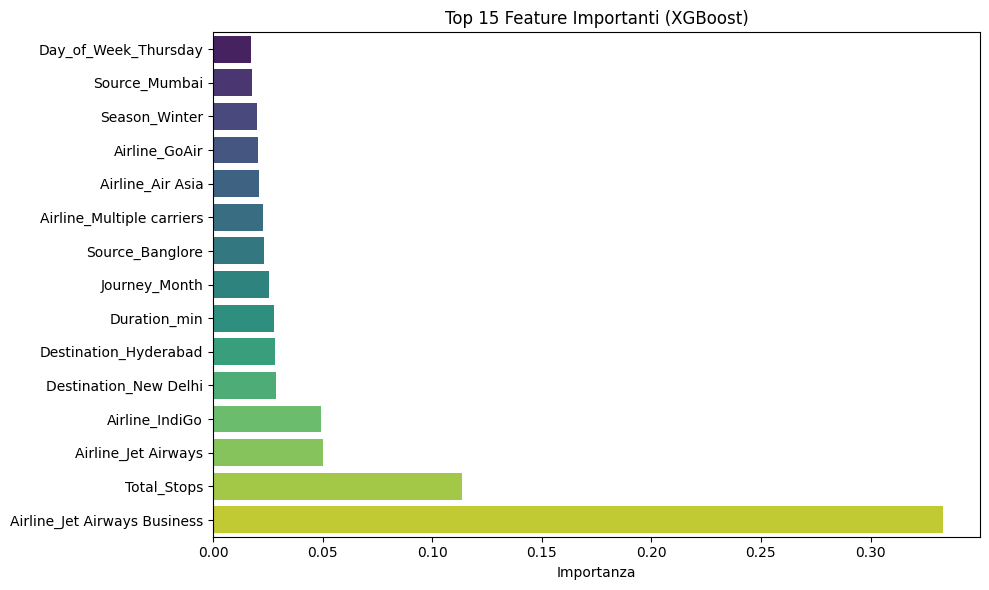

In [30]:
# Recupero dei nomi delle feature dopo OneHotEncoder
ohe = preprocess.named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(categorical_cols)

# Uniamo feature categoriche codificate e numeriche
all_features = np.concatenate([ohe_features, numeric_cols])
importances = xgb_model.feature_importances_

# Selezioniamo le top 15
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=all_features[indices], palette="viridis")
plt.title("Top 15 Feature Importanti (XGBoost)")
plt.xlabel("Importanza")
plt.tight_layout()
plt.show()